# 02 Single Coach Simulation

This notebook follows one long-distance coach `vehicle_journey_code` from TransXChange timing data into a single-charge feasibility check and SOC simulation. Coach journeys are modelled at journey level, not block level: distance is estimated from stop coordinates with a fixed detour factor, and infeasible journeys are labelled before the simulator can clamp SOC to zero.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_START = time.time()
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "mobility").exists() else NOTEBOOK_DIR
if not (REPO_ROOT / "mobility").exists():
    REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from mobility.core import DailySchedule, ParkingEvent, simulate_single_day
from mobility.core.simulator import STEP_HOURS, STEPS_PER_DAY
from mobility.coach import (
    journey_feasibility,
    journey_to_daily_schedules,
    load_all_coach_journeys,
    load_all_coach_stop_sequences,
    load_coach_fleet,
    render_journey_identity_card,
    sample_coach_ev,
    sample_contrast_journey,
    sample_protagonist_journey,
    simulate_coach_journey,
    summarize_journey_quality,
)

JOURNEYS_PATH = REPO_ROOT / "outputs" / "all_coach_journeys.parquet"
STOP_SEQUENCES_PATH = REPO_ROOT / "outputs" / "all_coach_stop_sequences.parquet"
MAIN_COACH_SEED = 20260501

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## Stage 0 - Units and Time Grid

,metric,value
0,SOC steps,96
1,load steps,96
2,STEP_HOURS,0.25
3,coach schedule unit,vehicle_journey_code
4,stub soc_end,1.0


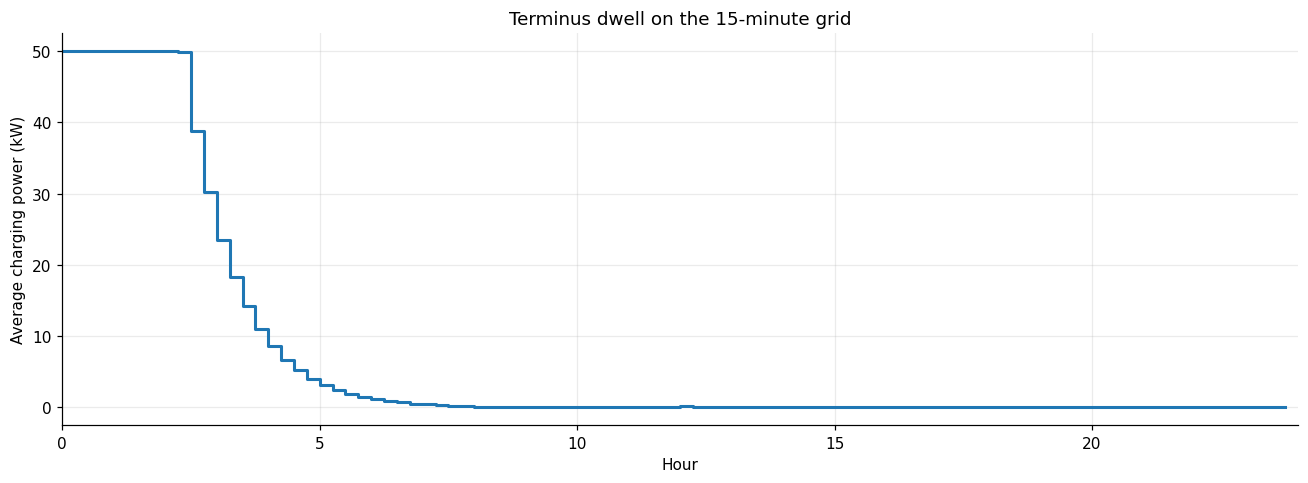

In [2]:
stub_schedule = DailySchedule(
    ev_id="coach_stage0_stub",
    day=0,
    day_type="representative_service_day",
    parking_events=[
        ParkingEvent(0.0, 8.0, 8.0, "terminus_dwell", can_charge=True, charge_power_kw=50.0),
        ParkingEvent(12.0, 24.0, 12.0, "terminus_dwell", can_charge=True, charge_power_kw=50.0),
    ],
)
stub_soc, stub_load_kw, stub_soc_end = simulate_single_day(stub_schedule, 281.0, soc_start=0.40)
display(
    pd.DataFrame(
        [
            ("SOC steps", len(stub_soc)),
            ("load steps", len(stub_load_kw)),
            ("STEP_HOURS", STEP_HOURS),
            ("coach schedule unit", "vehicle_journey_code"),
            ("stub soc_end", stub_soc_end),
        ],
        columns=["metric", "value"],
    )
)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
hours = np.arange(STEPS_PER_DAY) * STEP_HOURS
ax.step(hours, stub_load_kw, where="post", color="tab:blue", lw=2)
ax.set(xlabel="Hour", ylabel="Average charging power (kW)", title="Terminus dwell on the 15-minute grid")
ax.set_xlim(0, 24)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Stage A - Load All Coach Journeys

,value
total_journeys,14041.000000
known_distance_journeys,8550.000000
unknown_distance_journeys,5491.000000
known_distance_pct,60.893099
unknown_distance_pct,39.106901
cross_midnight_pct,11.466420
operator_coverage_pct,100.000000
runtime_coverage_pct,100.000000
n_operators,5.000000
simulatable_known_non_cross_midnight_journeys,7394.000000


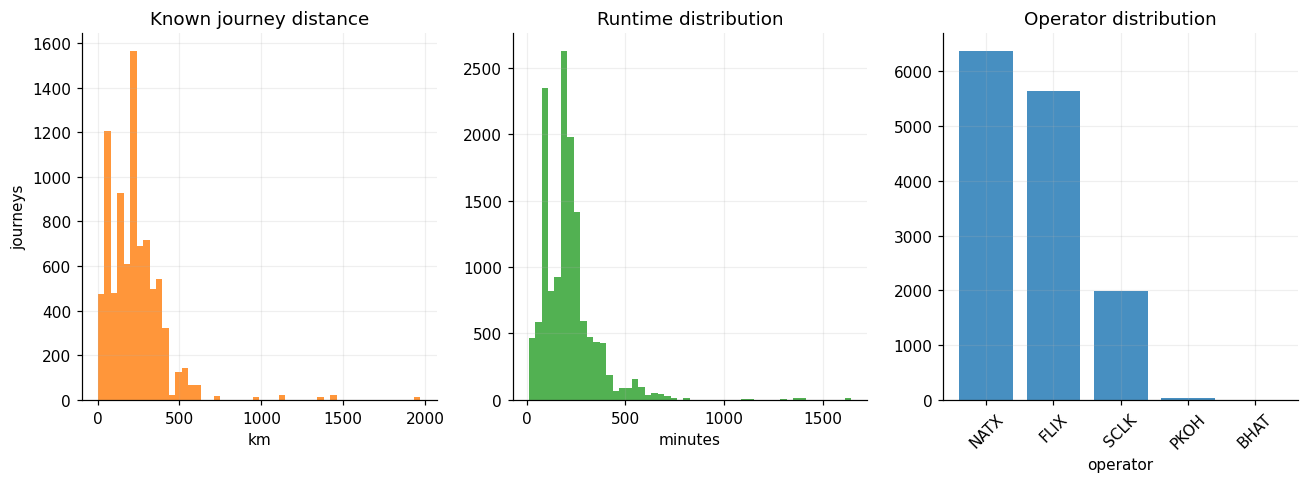

In [3]:
all_journeys = load_all_coach_journeys(JOURNEYS_PATH)
all_stop_sequences = load_all_coach_stop_sequences(STOP_SEQUENCES_PATH)
quality = summarize_journey_quality(all_journeys)
display(quality.T.rename(columns={0: "value"}))

known = all_journeys[all_journeys["distance_km"].notna()].copy()
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), dpi=110)
axes[0].hist(known["distance_km"], bins=50, color="tab:orange", alpha=0.82)
axes[0].set(title="Known journey distance", xlabel="km", ylabel="journeys")
axes[1].hist(all_journeys["runtime_min"], bins=50, color="tab:green", alpha=0.82)
axes[1].set(title="Runtime distribution", xlabel="minutes")
top_ops = all_journeys["operator_code"].value_counts().head(8)
axes[2].bar(top_ops.index.astype(str), top_ops.values, color="tab:blue", alpha=0.82)
axes[2].set(title="Operator distribution", xlabel="operator")
axes[2].tick_params(axis="x", rotation=45)
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Stage A.5 - Honest Labels

In [4]:
q = quality.iloc[0]
honest_labels = pd.DataFrame(
    [
        ("NaPTAN coordinate state", f"{q['known_distance_pct']:.1f}% known-distance journeys", "Missing any required stop coordinate makes the whole journey unknown."),
        ("Distance model", "haversine x 1.30", "This is not routed road distance; it is a transparent detour approximation."),
        ("Unknown-distance share", f"{q['unknown_distance_pct']:.1f}%", "Unknown-distance journeys are excluded from simulation selection."),
        ("Cross-midnight share", f"{q['cross_midnight_pct']:.1f}%", "The converter can split these, but random protagonist selection excludes them."),
        ("Calendar", "not expanded", "A row is a representative TxC vehicle journey, not a dated service."),
        ("Feasibility", "distributional", "One sampled EV spec is not a deterministic operator fleet assignment."),
    ],
    columns=["label", "observed value", "treatment"],
)
display(honest_labels)

,label,observed value,treatment
0,NaPTAN coordinate state,60.9% known-distance journeys,Missing any required stop coordinate makes the...
1,Distance model,haversine x 1.30,This is not routed road distance; it is a tran...
2,Unknown-distance share,39.1%,Unknown-distance journeys are excluded from si...
3,Cross-midnight share,11.5%,"The converter can split these, but random prot..."
4,Calendar,not expanded,"A row is a representative TxC vehicle journey,..."
5,Feasibility,distributional,One sampled EV spec is not a deterministic ope...


## Stage A.7 - Real Coach EV Fleet

,EV_ID,Model,Energy_kWh,DC_Power_kW,AC_Power_kW,efficiency_wh_per_km,consumption_kwh_per_km,LSOA_code,count
0,coach_12,YUTONG GTE14,563.0,150.0,22.0,1166.0,1.166,E01000615,5
1,coach_1,YUTONG TC12,281.0,150.0,22.0,810.0,0.810,E01000468,1


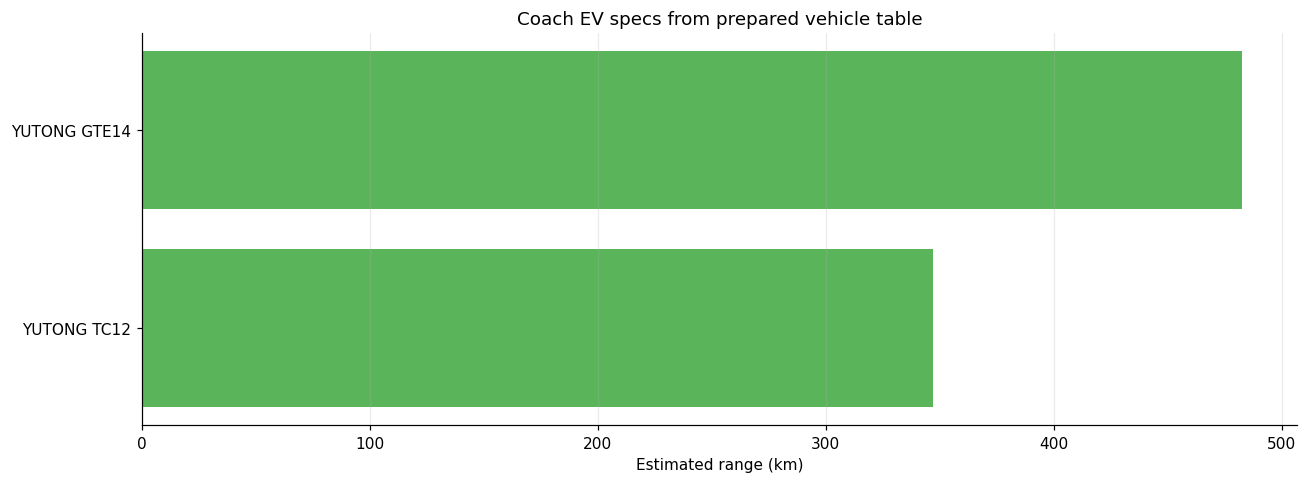

In [5]:
coach_fleet = load_coach_fleet()
coach_fleet_display = coach_fleet.copy()
coach_fleet_display["range_km"] = coach_fleet_display["Energy_kWh"] / coach_fleet_display["consumption_kwh_per_km"]
unique_coach_specs = (
    coach_fleet_display.drop_duplicates(["Model", "Energy_kWh", "consumption_kwh_per_km"])
    .sort_values("Model")
    .reset_index(drop=True)
)
display(
    unique_coach_specs[
        [
            "EV_ID",
            "Model",
            "Energy_kWh",
            "DC_Power_kW",
            "AC_Power_kW",
            "efficiency_wh_per_km",
            "consumption_kwh_per_km",
            "LSOA_code",
            "count",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ordered_fleet = unique_coach_specs.sort_values("range_km")
ax.barh(ordered_fleet["Model"], ordered_fleet["range_km"], color="tab:green", alpha=0.78)
ax.set(xlabel="Estimated range (km)", title="Coach EV specs from prepared vehicle table")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Stage B - Random Protagonist and Contrast

In [6]:
rng = np.random.default_rng(MAIN_COACH_SEED)
protagonist = sample_protagonist_journey(all_journeys, rng)
contrast = sample_contrast_journey(all_journeys, rng, protagonist)
ev_spec = sample_coach_ev(coach_fleet, rng, weight_by_count=True)

protagonist_stops = all_stop_sequences[all_stop_sequences["journey_id"] == protagonist["journey_id"]].sort_values("stop_sequence")
contrast_stops = all_stop_sequences[all_stop_sequences["journey_id"] == contrast["journey_id"]].sort_values("stop_sequence")

display(pd.DataFrame([protagonist[["journey_id", "operator_code", "line_name", "departure_time", "arrival_time", "distance_km"]]]))
display(pd.DataFrame([contrast[["journey_id", "operator_code", "line_name", "departure_time", "arrival_time", "distance_km"]]]))
display(pd.DataFrame([ev_spec]))

,journey_id,operator_code,line_name,departure_time,arrival_time,distance_km
4774,FLIX-FlixBus-UK005-London-Leicester.xml::VJ32,FLIX,UK005,14:00:00,17:00:00,191.321663


,journey_id,operator_code,line_name,departure_time,arrival_time,distance_km
2026,FLIX-FlixBus-UK002-London-Bradford.xml::VJ44,FLIX,UK002,17:00:00,22:55:00,382.659577


,EV_ID,Model,Energy_kWh,DC_Power_kW,AC_Power_kW,efficiency_wh_per_km,consumption_kwh_per_km,LSOA_code,count
120,coach_143,YUTONG GTE14,563.0,150.0,22.0,1166.0,1.166,E01034579,13


## Stage C - Daily Schedules and Gantt

,day,n_trips,n_terminus_dwell,trip_km
0,0,1,2,191.321663


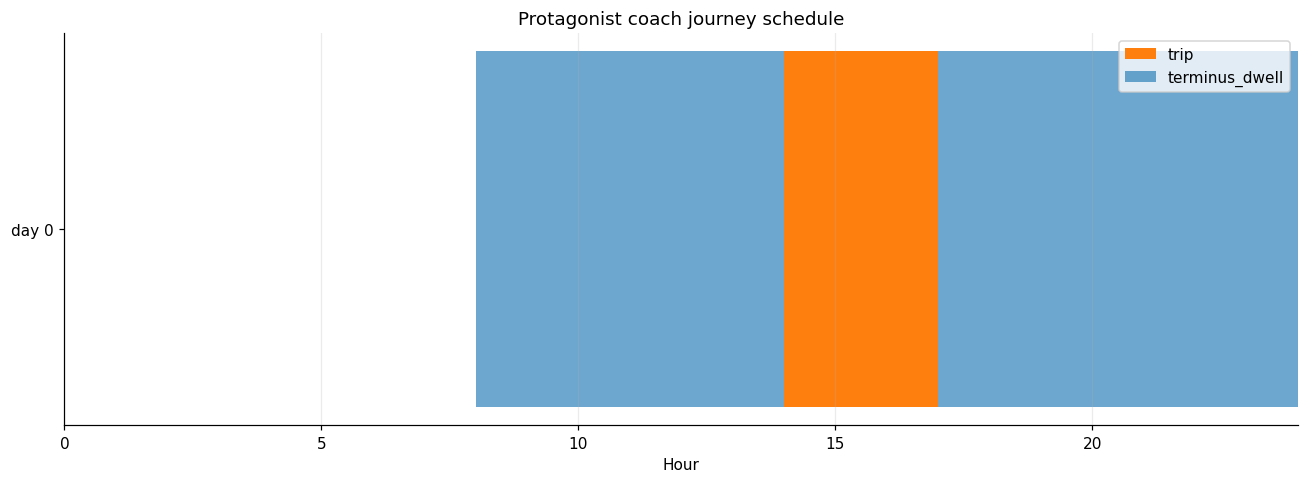

In [7]:
schedules = journey_to_daily_schedules(
    protagonist,
    protagonist_stops,
    consumption_kwh_per_km=ev_spec["consumption_kwh_per_km"],
    terminus_charge_kw=50.0,
)

def plot_gantt(schedules, title):
    fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
    for y, schedule in enumerate(schedules):
        for trip in schedule.trips:
            ax.barh(y, trip.arrival_time - trip.departure_time, left=trip.departure_time, color="tab:orange", label="trip")
        for event in schedule.parking_events:
            ax.barh(y, event.end_time - event.start_time, left=event.start_time, color="tab:blue", alpha=0.65, label="terminus_dwell")
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right")
    ax.set(yticks=range(len(schedules)), yticklabels=[f"day {s.day}" for s in schedules], xlabel="Hour", title=title)
    ax.set_xlim(0, 24)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

display(pd.DataFrame([
    {
        "day": schedule.day,
        "n_trips": len(schedule.trips),
        "n_terminus_dwell": sum(event.location_purpose == "terminus_dwell" for event in schedule.parking_events),
        "trip_km": sum(trip.distance_km for trip in schedule.trips),
    }
    for schedule in schedules
]))
plot_gantt(schedules, "Protagonist coach journey schedule")

## Stage D - Feasibility Then Simulation

,feasible_single_charge,energy_required_kwh,usable_energy_kwh,shortfall_kwh,min_soc_required
0,True,223.081059,534.85,0.0,0.446236


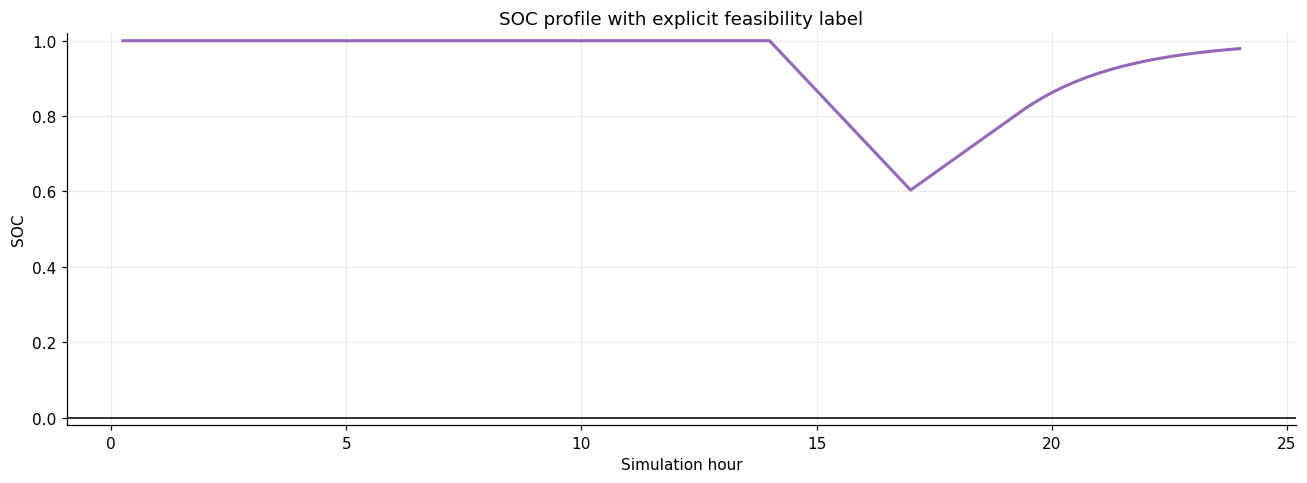

In [8]:
feasibility = journey_feasibility(
    protagonist["distance_km"],
    battery_kwh=ev_spec["Energy_kWh"],
    consumption_kwh_per_km=ev_spec["consumption_kwh_per_km"],
)
result = simulate_coach_journey(protagonist, protagonist_stops, ev_spec, terminus_charge_kw=50.0, soc_init=1.0)
display(pd.DataFrame([feasibility]))

soc = result["soc"]
hours = np.arange(1, len(soc) + 1) * STEP_HOURS
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
ax.plot(hours, soc, color="tab:purple", lw=2)
ax.axhline(0.0, color="black", lw=1)
if not feasibility["feasible_single_charge"]:
    for spine in ax.spines.values():
        spine.set_edgecolor("red")
        spine.set_linewidth(2.5)
if result["soc_floor_hit_h"] is not None:
    ax.axvline(result["soc_floor_hit_h"], color="red", ls="--", lw=1.5)
ax.set(xlabel="Simulation hour", ylabel="SOC", ylim=(-0.02, 1.02), title="SOC profile with explicit feasibility label")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Stage E - Feasibility Frontier

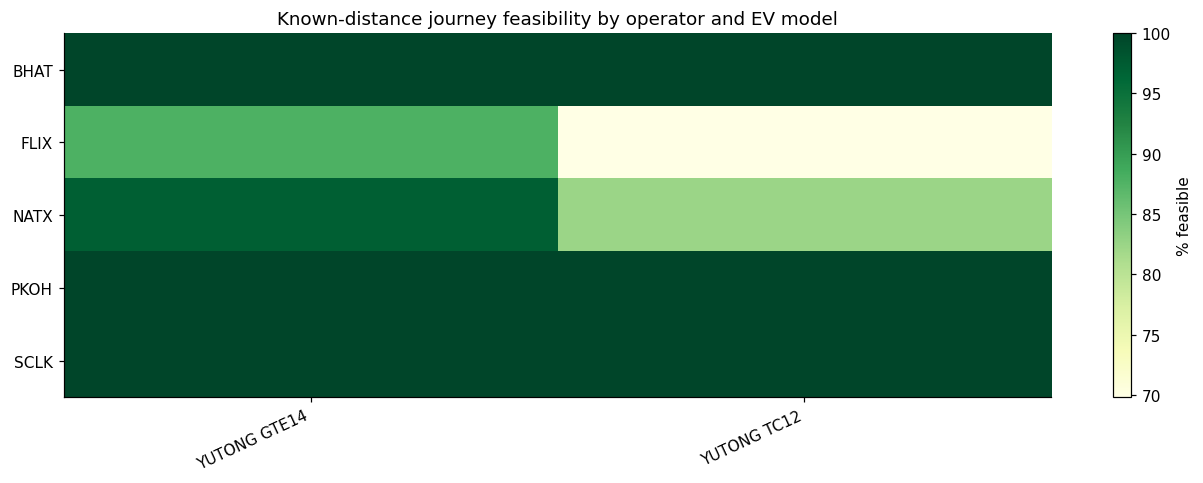

,journey,distance_percentile
0,protagonist,42.467836
1,contrast,88.573099


In [9]:
candidates = all_journeys[all_journeys["distance_km"].notna()].copy()
simulatable_fleet = coach_fleet.drop_duplicates(["Model", "Energy_kWh", "consumption_kwh_per_km"]).copy()
frontier_rows = []
for _, ev in simulatable_fleet.iterrows():
    feasible = candidates["distance_km"].apply(
        lambda km: journey_feasibility(
            float(km),
            battery_kwh=float(ev["Energy_kWh"]),
            consumption_kwh_per_km=float(ev["consumption_kwh_per_km"]),
        )["feasible_single_charge"]
    )
    for operator, values in feasible.groupby(candidates["operator_code"]):
        frontier_rows.append({"EV model": ev["Model"], "operator": operator, "pct_feasible": float(values.mean() * 100.0)})
frontier = pd.DataFrame(frontier_rows)
heat = frontier.pivot(index="operator", columns="EV model", values="pct_feasible").fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
im = ax.imshow(heat.values, aspect="auto", cmap="YlGn")
ax.set_xticks(np.arange(heat.shape[1]), heat.columns, rotation=25, ha="right")
ax.set_yticks(np.arange(heat.shape[0]), heat.index)
ax.set(title="Known-distance journey feasibility by operator and EV model")
fig.colorbar(im, ax=ax, label="% feasible")
plt.tight_layout()
plt.show()

protagonist_percentile = (candidates["distance_km"] <= protagonist["distance_km"]).mean() * 100.0
contrast_percentile = (candidates["distance_km"] <= contrast["distance_km"]).mean() * 100.0
display(pd.DataFrame([{"journey": "protagonist", "distance_percentile": protagonist_percentile}, {"journey": "contrast", "distance_percentile": contrast_percentile}]))

## Stage F - 3x3 Sensitivity

In [10]:
battery_values = [281.0, 400.0, 563.0]
consumption_values = [0.81, 1.17, 1.5]
sensitivity = pd.DataFrame(
    [
        {
            "battery_kwh": battery,
            "consumption_kwh_per_km": consumption,
            "feasible_single_charge": journey_feasibility(
                protagonist["distance_km"],
                battery_kwh=battery,
                consumption_kwh_per_km=consumption,
            )["feasible_single_charge"],
        }
        for battery in battery_values
        for consumption in consumption_values
    ]
)
display(sensitivity.pivot(index="battery_kwh", columns="consumption_kwh_per_km", values="feasible_single_charge"))

consumption_kwh_per_km,0.81,1.17,1.50
battery_kwh,,,
281.0,True,True,False
400.0,True,True,True
563.0,True,True,True


## Stage G - Optional Operator Comparison

,n_journeys,pct_known_distance
operator_code,,
NATX,6376,80.379548
FLIX,5636,53.743790
SCLK,1993,19.468138
PKOH,30,20.000000
BHAT,6,33.333333


,skipped_operator,reason
0,SCLK,pct_known_distance < 50%
1,PKOH,pct_known_distance < 50%
2,BHAT,pct_known_distance < 50%


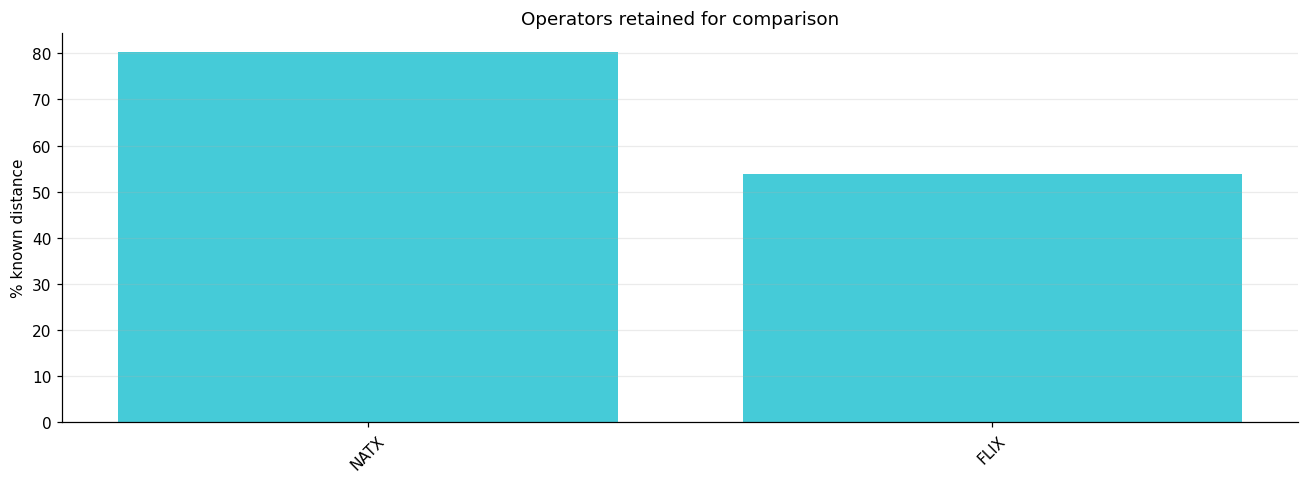

In [11]:
operator_quality = (
    all_journeys.assign(known_distance=all_journeys["distance_km"].notna())
    .groupby("operator_code")
    .agg(n_journeys=("journey_id", "count"), pct_known_distance=("known_distance", lambda s: float(s.mean() * 100.0)))
    .sort_values("n_journeys", ascending=False)
)
included = operator_quality[operator_quality["pct_known_distance"] >= 50.0]
skipped = operator_quality[operator_quality["pct_known_distance"] < 50.0]
display(operator_quality)
display(pd.DataFrame({"skipped_operator": skipped.index, "reason": "pct_known_distance < 50%"}))

if not included.empty:
    fig, ax = plt.subplots(figsize=(12, 4.5), dpi=110)
    ax.bar(included.index.astype(str), included["pct_known_distance"], color="tab:cyan", alpha=0.8)
    ax.set(ylabel="% known distance", title="Operators retained for comparison")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## Stage H - Identity Card

In [12]:
identity_card = render_journey_identity_card(
    protagonist,
    ev_spec,
    result["feasibility"],
    wall_clock_s=time.time() - NOTEBOOK_START,
)
display(identity_card.T.rename(columns={0: "value"}))

,value
operator,FlixBus
operator_code,FLIX
vehicle_journey_code,VJ32
route,UK005
service_code,UZ000FLIX:UK005
start_time,14:00:00
end_time,17:00:00
duration_h,3.0
distance_km,191.321663
distance_source,haversine_x_detour
